<a href="https://colab.research.google.com/github/ferrygea/ATS_Ferry-Foranda/blob/main/ATS_Ferry_Foranda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Karakter Tulisan Tangan EMNIST dengan HOG Feature Extraction dan SVM

## Informasi Mata Kuliah

- **Mata Kuliah**: Machine Vision
- **Kode Mata Kuliah**: MK521
- **Tahun Akademik**: Ganjil 2025/2026
- **Program Studi**: Teknik Mekatronika

## Spesifikasi Program

- **Dataset**: emnist-letters-train (26 classes: A-Z)
- **Jumlah Sampel**: 13,000 sampel dengan distribusi seimbang (500 sampel per kelas)
- **Feature Extraction**: HOG (Histogram of Oriented Gradients)
- **Classifier**: Support Vector Machine (SVM)
- **Metode Evaluasi**: Leave-One-Out-Cross-Validation (LOOCV)
- **Metrik Evaluasi**: Confusion Matrix, Accuracy, Precision, F1-Score


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


gpu_available = False
try:
    import cupy as cp
    import cudf
    from cuml.svm import SVC as cuSVC
    from cuml.model_selection import train_test_split as cu_train_test_split
    gpu_available = True
except Exception as e:
    gpu_available = False

print("Libraries diimport.")

Libraries diimport.


In [4]:

DATASET_DIR = Path("Dataset")
TRAIN_CSV = DATASET_DIR / "/content/drive/MyDrive/Dataset/emnist-letters-train.csv"
MAPPING_FILE = DATASET_DIR / "/content/drive/MyDrive/Dataset/emnist-letters-mapping.txt"

if not TRAIN_CSV.exists():
	raise FileNotFoundError(f"Dataset file not found: {TRAIN_CSV}")
if not MAPPING_FILE.exists():
	raise FileNotFoundError(f"Mapping file not found: {MAPPING_FILE}")

print(f"Dataset ditemukan: {TRAIN_CSV}")
print(f"Mapping file ditemukan: {MAPPING_FILE}")

Dataset ditemukan: /content/drive/MyDrive/Dataset/emnist-letters-train.csv
Mapping file ditemukan: /content/drive/MyDrive/Dataset/emnist-letters-mapping.txt


In [5]:

def load_emnist_letters_from_csv(csv_path: Path):
	"""Load EMNIST Letters dataset from CSV file."""
	df = pd.read_csv(csv_path, header=None)
	labels = df.iloc[:, 0].values.astype(np.int64) - 1
	images_flat = df.iloc[:, 1:].values.astype(np.uint8)
	images = images_flat.reshape(-1, 28, 28)
	images = np.transpose(images, (0, 2, 1))
	images = np.flip(images, axis=2)
	return images, labels

print("Memuat dataset dari CSV...")
X_all, y_all = load_emnist_letters_from_csv(TRAIN_CSV)
print(f"Dataset berhasil dimuat: {X_all.shape[0]} sampel")
print(f"Dimensi gambar: {X_all[0].shape}")
print(f"Range label: {y_all.min()} sampai {y_all.max()} (A-Z)")

Memuat dataset dari CSV...
Dataset berhasil dimuat: 88800 sampel
Dimensi gambar: (28, 28)
Range label: 0 sampai 25 (A-Z)



Visualisasi sampel dataset awal...


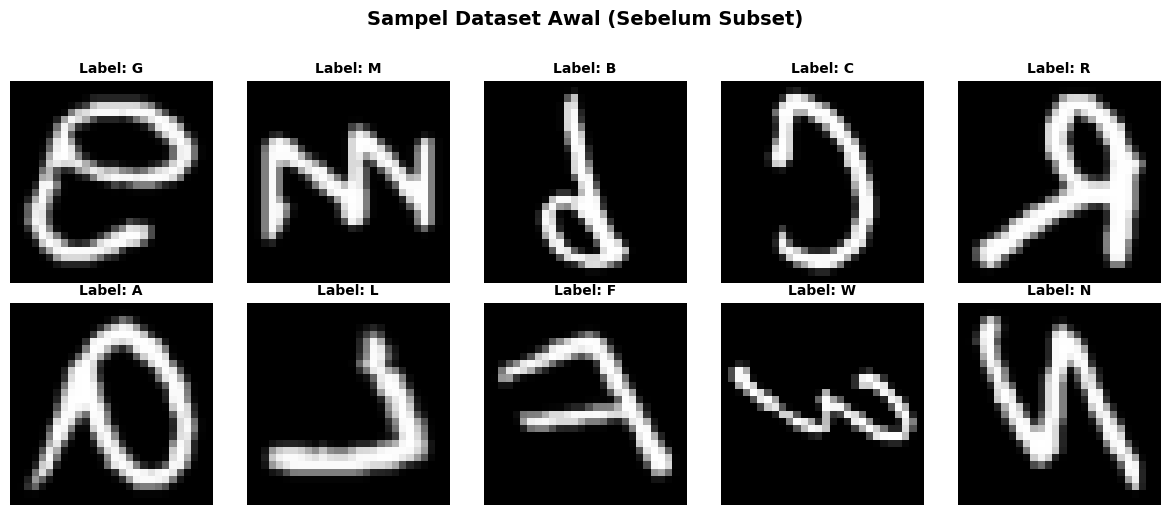

Total sampel dataset awal: 88800


In [6]:

print("\nVisualisasi sampel dataset awal...")

NUM_CLASSES = 26
SAMPLES_PER_CLASS = 500

np.random.seed(42)
sample_indices = np.random.choice(len(X_all), size=min(10, len(X_all)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    img = X_all[sample_idx]
    label = chr(y_all[sample_idx] + ord('A'))

    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'Label: {label}', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sampel Dataset Awal (Sebelum Subset)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total sampel dataset awal: {len(X_all)}")


In [7]:
from collections import defaultdict
def build_balanced_subset(images: np.ndarray, labels: np.ndarray,
						   per_class: int = SAMPLES_PER_CLASS,
						   random_state: int = 42):
	rng = np.random.default_rng(random_state)
	indices_by_class = defaultdict(list)
	for idx, lab in enumerate(labels):
		indices_by_class[int(lab)].append(idx)

	selected_indices = []
	for lab in range(NUM_CLASSES):
		candidates = indices_by_class[lab]
		if len(candidates) < per_class:
			raise ValueError(f"Class {lab} has only {len(candidates)} samples")
		selected = rng.choice(candidates, size=per_class, replace=False)
		selected_indices.extend(selected.tolist())

	selected_indices = np.array(selected_indices)
	rng.shuffle(selected_indices)
	return images[selected_indices], labels[selected_indices]

print("Membuat subset seimbang...")
X, y = build_balanced_subset(X_all, y_all)
print(f"Subset berhasil dibuat: {X.shape[0]} sampel")
print(f"Distribusi: {SAMPLES_PER_CLASS} sampel per kelas ({NUM_CLASSES} kelas)")
print("Jumlah sample final:", len(X), len(y))


Membuat subset seimbang...
Subset berhasil dibuat: 13000 sampel
Distribusi: 500 sampel per kelas (26 kelas)
Jumlah sample final: 13000 13000



Menampilkan sampel gambar dari setiap kelas...


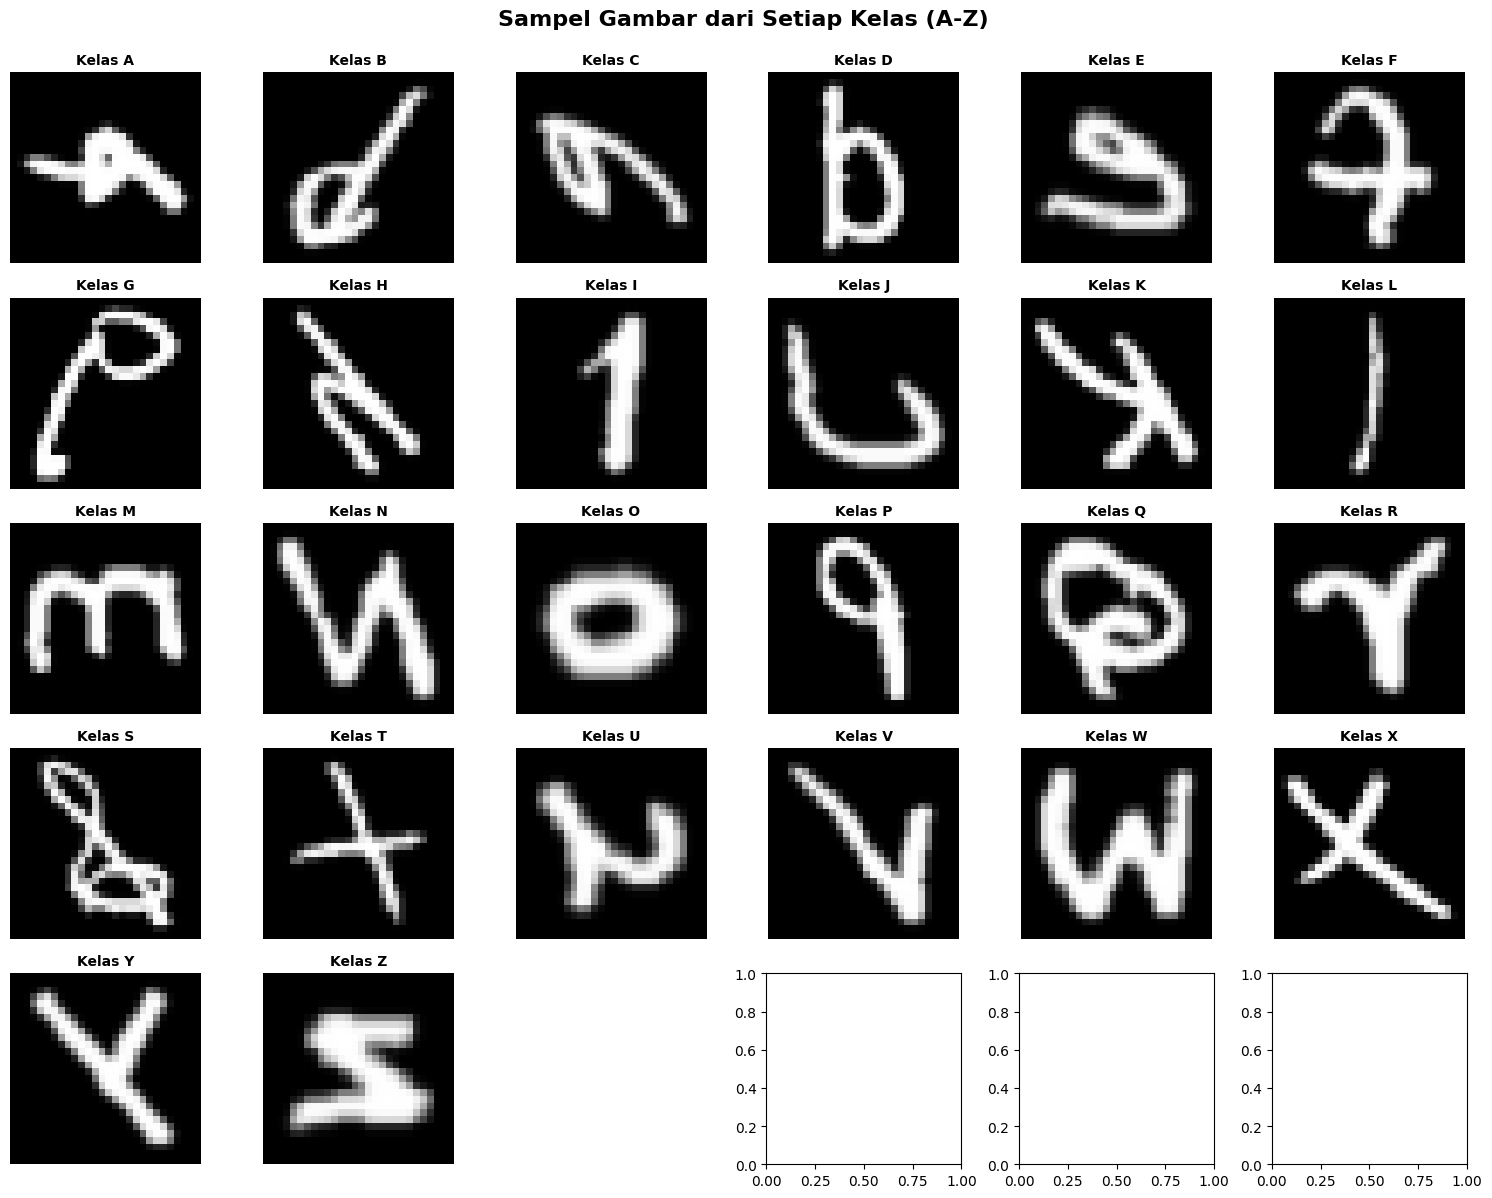


✓ Subset seimbang berhasil dibuat!
  - Total sampel: 13000
  - Jumlah kelas: 26
  - Sampel per kelas: 500


In [8]:

print("\nMenampilkan sampel gambar dari setiap kelas...")
fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

for class_idx in range(NUM_CLASSES):
    class_mask = y == class_idx
    class_indices = np.where(class_mask)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        img = X[sample_idx]
        label = chr(class_idx + ord('A'))

        axes[class_idx].imshow(img, cmap='gray')
        axes[class_idx].set_title(f'Kelas {label}',
                                  fontsize=10, fontweight='bold')
        axes[class_idx].axis('off')

if NUM_CLASSES < len(axes):
    axes[NUM_CLASSES].axis('off')

plt.suptitle('Sampel Gambar dari Setiap Kelas (A-Z)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n✓ Subset seimbang berhasil dibuat!")
print(f"  - Total sampel: {len(X)}")
print(f"  - Jumlah kelas: {NUM_CLASSES}")
print(f"  - Sampel per kelas: {SAMPLES_PER_CLASS}")


In [9]:

from skimage.feature import hog

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM = "L2-Hys"

def compute_hog_features(images: np.ndarray):
	"""Ekstrak fitur HOG dari setiap gambar."""
	features = []
	for img in tqdm(images, desc="Extracting HOG features"):
		feat = hog(img / 255.0,
				 orientations=HOG_ORIENTATIONS,
				 pixels_per_cell=HOG_PIXELS_PER_CELL,
				 cells_per_block=HOG_CELLS_PER_BLOCK,
				 block_norm=HOG_BLOCK_NORM,
				 visualize=False,
				 feature_vector=True)
		features.append(feat)
	return np.asarray(features, dtype=np.float32)

print("Memulai ekstraksi fitur HOG...")
print(f"Parameter HOG: orientations={HOG_ORIENTATIONS}, pixels_per_cell={HOG_PIXELS_PER_CELL}, cells_per_block={HOG_CELLS_PER_BLOCK}")
X_hog = compute_hog_features(X)
print(f"Ekstraksi HOG selesai. Dimensi fitur: {X_hog.shape}")
print(f"Jumlah sampel: {X_hog.shape[0]}, Dimensi fitur: {X_hog.shape[1]}")


Memulai ekstraksi fitur HOG...
Parameter HOG: orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)


Extracting HOG features: 100%|██████████| 13000/13000 [00:02<00:00, 5154.53it/s]

Ekstraksi HOG selesai. Dimensi fitur: (13000, 144)
Jumlah sampel: 13000, Dimensi fitur: 144


Membuat classifier SVM...
Parameter SVM: C=1.0, kernel=rbf, gamma=scale

Memulai evaluasi dengan LOOCV...
Total sampel: 13000
Jumlah folds: 13000 (satu fold per sampel)
Accuracy: 0.8615
Precision: 0.8636
Recall: 0.8615
F1-Score: 0.8617


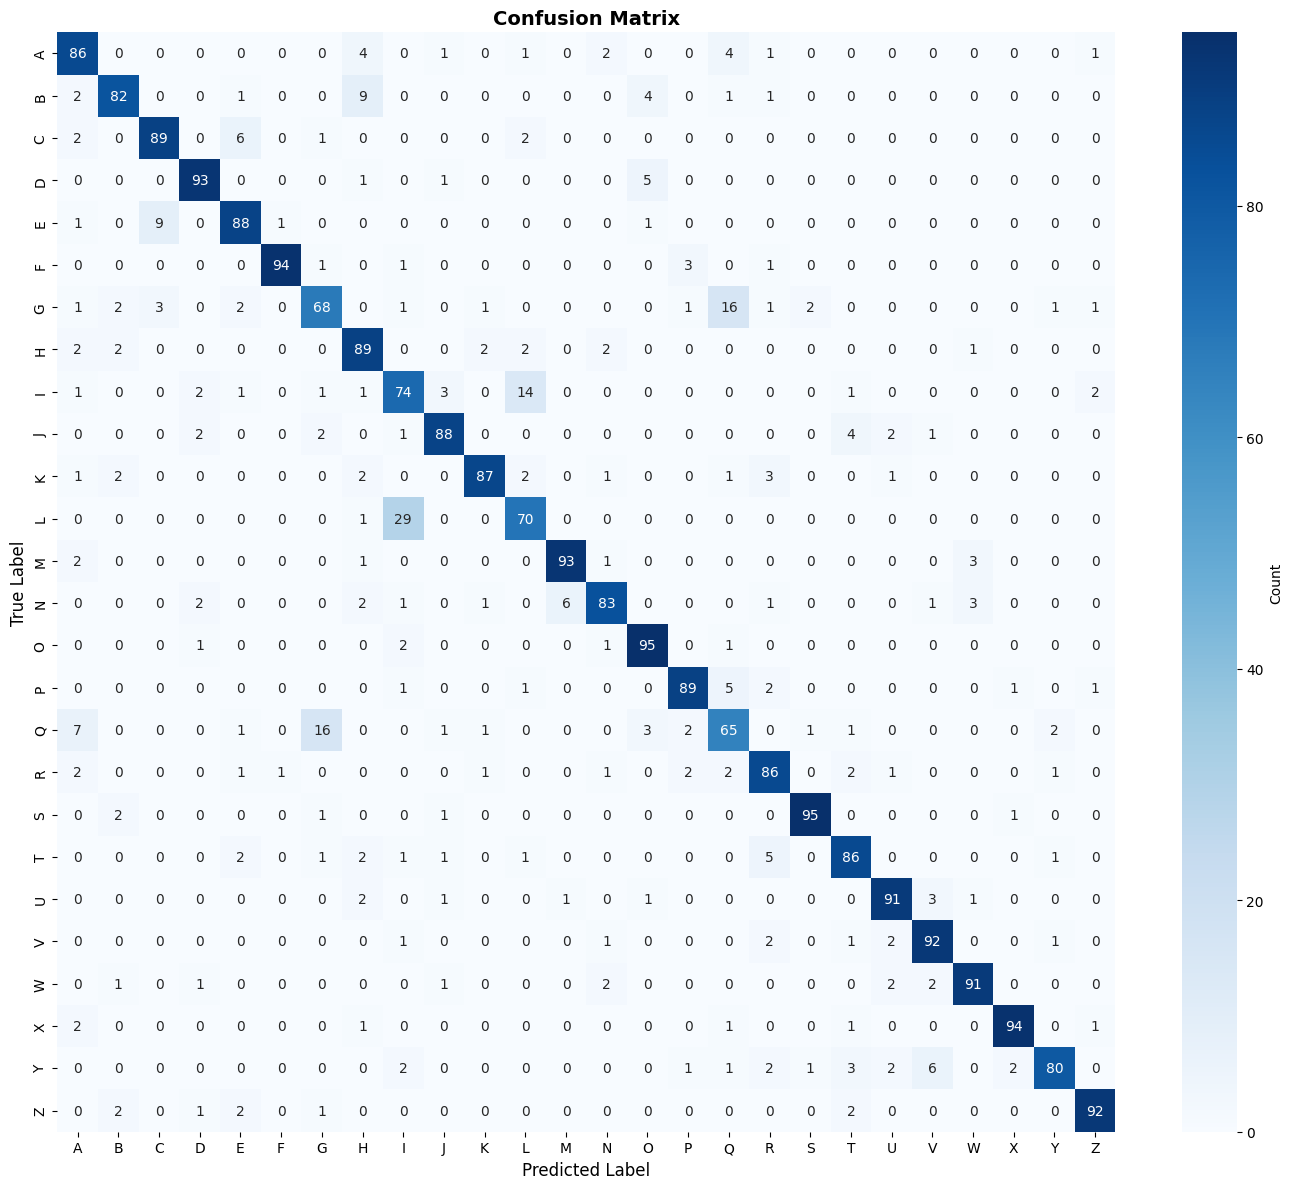

In [11]:

from sklearn.model_selection import LeaveOneOut, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

SVM_C = 1.0
SVM_KERNEL = 'rbf'
SVM_GAMMA = 'scale'

print("Membuat classifier SVM...")
print(f"Parameter SVM: C={SVM_C}, kernel={SVM_KERNEL}, gamma={SVM_GAMMA}")
print(f'\nMemulai evaluasi dengan LOOCV...')
print(f'Total sampel: {len(y)}')
print(f'Jumlah folds: {len(y)} (satu fold per sampel)')

if gpu_available:
    X_hog_cp = cp.asarray(X_hog).astype(cp.float32)
    y_cp = cp.asarray(y).astype(cp.int32)
    clf = cuSVC(C=SVM_C, kernel=SVM_KERNEL, gamma=SVM_GAMMA)
    Xtr_cp, Xte_cp, ytr_cp, yte_cp = cu_train_test_split(X_hog_cp, y_cp, test_size=0.2, random_state=42, stratify=y_cp)
    clf.fit(Xtr_cp, ytr_cp)
    y_pred_cp = clf.predict(Xte_cp)
    y_pred = cp.asnumpy(y_pred_cp).astype(int)
    y_true = cp.asnumpy(yte_cp).astype(int)
else:
    from sklearn.svm import SVC
    clf = SVC(C=SVM_C, kernel=SVM_KERNEL, gamma=SVM_GAMMA, random_state=42)
    cv = LeaveOneOut()
    y_pred = cross_val_predict(clf, X_hog, y, cv=cv, n_jobs=-1)
    y_true = y

cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(NUM_CLASSES), average='macro', zero_division=0)

class_labels = [chr(i + ord('A')) for i in range(NUM_CLASSES)]
prec_per_class, rec_per_class, f1_per_class, _ = precision_recall_fscore_support(
	y_true, y_pred, labels=np.arange(NUM_CLASSES), average=None, zero_division=0)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-Score: {f1:.4f}')

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


In [15]:

OUT_DIR = Path("/content/drive/MyDrive/Dataset/Output")
OUT_DIR.mkdir(exist_ok=True, parents=True)

print("Menyimpan hasil evaluasi...")

metrics = {
	"accuracy": float(acc),
	"precision_macro": float(prec),
	"recall_macro": float(rec),
	"f1_macro": float(f1),
}
pd.DataFrame([metrics]).to_csv(OUT_DIR / "metrics_loocv.csv", index=False)
print(f"✓ Metrik overall tersimpan: {OUT_DIR / 'metrics_loocv.csv'}")

per_class_metrics = pd.DataFrame({
	'Class': class_labels,
	'Precision': prec_per_class,
	'Recall': rec_per_class,
	'F1_Score': f1_per_class
})
per_class_metrics.to_csv(OUT_DIR / "metrics_per_class.csv", index=False)
print(f"✓ Metrik per kelas tersimpan: {OUT_DIR / 'metrics_per_class.csv'}")

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", annot=True, fmt="d",
			xticklabels=class_labels, yticklabels=class_labels,
			cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_loocv.png", dpi=200, bbox_inches='tight')
plt.close()
print(f"✓ Confusion matrix tersimpan: {OUT_DIR / 'confusion_matrix_loocv.png'}")


Menyimpan hasil evaluasi...
✓ Metrik overall tersimpan: /content/drive/MyDrive/Dataset/Output/metrics_loocv.csv
✓ Metrik per kelas tersimpan: /content/drive/MyDrive/Dataset/Output/metrics_per_class.csv
✓ Confusion matrix tersimpan: /content/drive/MyDrive/Dataset/Output/confusion_matrix_loocv.png


In [17]:

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split

print('Memulai parameter tuning...')
DEV_FRACTION = 0.3
X_dev, _, y_dev, _ = train_test_split(X_hog, y, test_size=1-DEV_FRACTION, stratify=y, random_state=42)
print(f'Menggunakan {len(y_dev)} sampel untuk tuning')

param_grid_svm = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear', 'poly']
}

print('Menjalankan GridSearchCV...')
gs_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)
gs_svm.fit(X_dev, y_dev)

print('\nParameter tuning selesai.')
print(f'Parameter terbaik: {gs_svm.best_params_}')
print(f'Score terbaik: {gs_svm.best_score_:.4f}')


Memulai parameter tuning...
Menggunakan 3900 sampel untuk tuning
Menjalankan GridSearchCV...

Parameter tuning selesai.
Parameter terbaik: {'C': 5.0, 'gamma': 'scale', 'kernel': 'rbf'}
Score terbaik: 0.8190
